In [2]:
import sys
import os

sys.path.insert(0, os.path.abspath(".."))

import seaborn as sns
import matplotlib.pyplot as plt
from etl import run_etl
from etl import DOMINIOS, DC_LABELS, EDUCATION_LEVEL, DC_LABELS,DC_ORDER

In [3]:
# Extraer los datos desde el pipeline de ETL y obtener los DataFrames resultantes
df_tabla_0_imp, df_tabla_1_imp, df_complete = run_etl(dotenv_path="../../.env")

Descargando datos desde GitHub...
Hojas cargadas: 125
Tabla 0 (escolaridad baja) : 36
Tabla 1 (escolaridad alta) : 81
No determinadas            : 8
df_tabla_0 crudo : (36, 32)
df_tabla_1 crudo : (81, 29)

🔧  Imputando nulos...
--- Perfil nulos Tabla 0 ---
                                         nulos  %_nulos dtype  n_unicos
fluidez_verbal_semantica                    23    63.89   str         4
matrices                                    12    33.33   str         4
imagenes_sobrepuestas                       11    30.56   str         3
stroop_interferencia                         9    25.00   str         4
material_verbal_complejo                     6    16.67   str         3
denominacion                                 5    13.89   str         1
stroop_palabra                               4    11.11   str         4
stroop_color                                 4    11.11   str         4
atencion_sostenida_visual                    4    11.11   str         4
evocacion_diferida     

In [4]:
#Configuraciones para las gráficas
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 110})

DC_PALETTE = {0: "#2ecc71", 1: "#f39c12", 2: "#e74c3c"} #Paleta de colores para las gráficas
DOMINIOS_COGNITIVOS = DOMINIOS.keys()

In [9]:
df_complete.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
sheet_name,117,117,GC1-60,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
nivel_estudio,117.0,NaN,NaN,NaN,0.692308,0.463524,0.0,0.0,1.0,1.0,1.0
dc,117.0,NaN,NaN,NaN,1.042735,0.711884,0.0,1.0,1.0,2.0,2.0
age,117.0,NaN,NaN,NaN,70.74359,9.698164,51.0,65.0,71.0,77.0,96.0
orientacion,117.0,NaN,NaN,NaN,2.849003,0.935154,1.0,2.333333,3.0,4.0,4.0
atencion,117.0,NaN,NaN,NaN,2.817664,0.378722,1.666667,2.666667,3.0,3.0,3.666667
lenguaje,117.0,NaN,NaN,NaN,3.341168,0.547874,2.0,3.0,3.5,3.75,4.0
memoria_verbal,117.0,NaN,NaN,NaN,2.578632,0.436844,1.0,2.25,2.6,3.0,4.0
memoria_visual,117.0,NaN,NaN,NaN,2.740741,0.424605,1.0,2.666667,2.666667,3.0,4.0
gnosias,117.0,NaN,NaN,NaN,3.495726,0.726635,2.0,3.0,4.0,4.0,4.0


## Distribución de edad

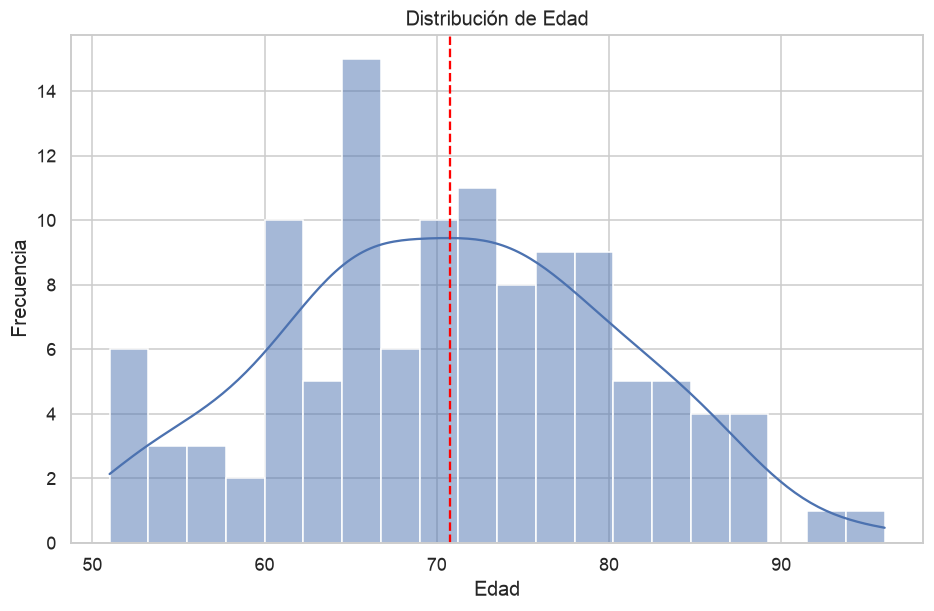

In [5]:
#Distribución de edad general de toda la población
plt.figure(figsize=(10, 6))
sns.histplot(data=df_complete, x="age_num", palette=DC_PALETTE, bins=20, kde=True)
plt.title("Distribución de Edad")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
##linea vertical de la media
plt.axvline(df_complete["age_num"].mean(), color="red", linestyle="--", label="Media")
plt.show()

## Distribución del nivel de estudio

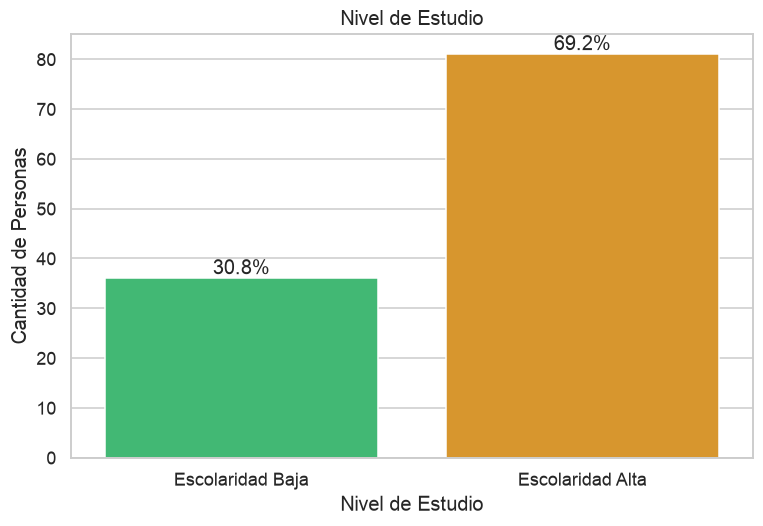

In [6]:
# Nivel de estudio de todo el dataset
plt.figure(figsize=(8, 5))
boxes = sns.countplot(data=df_complete, x="nivel_estudio", palette=[DC_PALETTE[0], DC_PALETTE[1]])
#añadir el porcentaje encima de cada barra
for p in boxes.patches:
    height = p.get_height()
    percentage = f"{(height / len(df_complete) * 100):.1f}%"
    boxes.annotate(percentage, (p.get_x() + p.get_width() / 2., height), ha="center", va="bottom")
plt.title("Nivel de Estudio")
plt.xlabel("Nivel de Estudio")
plt.ylabel("Cantidad de Personas")
plt.xticks(ticks=[0, 1], labels=["Escolaridad Baja", "Escolaridad Alta"])
plt.show()


## Distribución de deterioro cognitivo en la muestra

(0.0, 72.5)

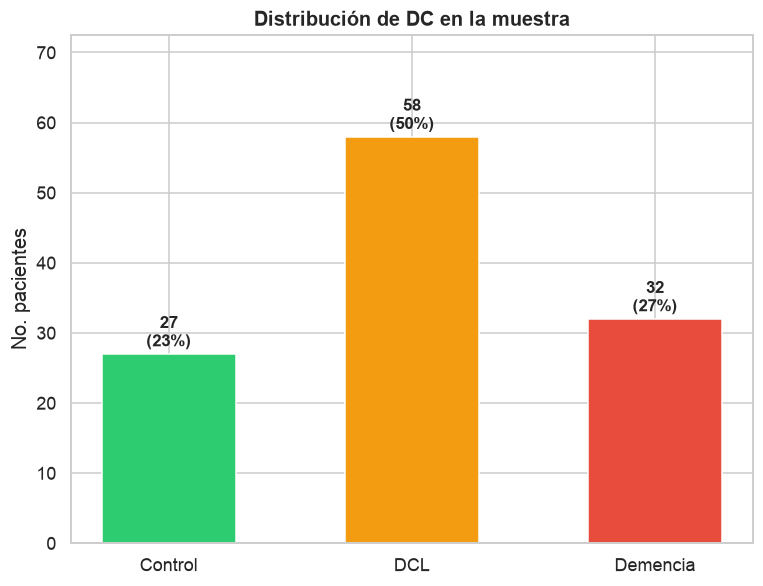

In [8]:
fig = plt.figure(figsize=(8, 6))

# GRÁFICO DE DISTRIBUCIÓN DE LOS DATOS
counts = df_complete["dc"].value_counts().sort_index()
x_pos = list(range(len(DC_ORDER)))
bars = plt.bar(
    x_pos,
    [counts.get(k, 0) for k in DC_ORDER],
    color=DC_PALETTE.values(),
    edgecolor="white", width=0.55,
)
for bar, k in zip(bars, DC_ORDER):
    v   = counts.get(k, 0)
    pct = v / len(df_complete) * 100
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.4,
        f"{v}\n({pct:.0f}%)",
        ha="center", va="bottom", fontsize=11, fontweight="bold",
    )
plt.xticks(ticks=x_pos, labels=[DC_LABELS[k] for k in DC_ORDER])
plt.ylabel("No. pacientes")
plt.title("Distribución de DC en la muestra", fontweight="bold")
plt.ylim(0, counts.max() * 1.25)